# Challenge 3: evaluación final e inferencia

El modelo ya fue seleccionado. Ahora debes abrir el conjunto de test una sola vez, comunicar su desempeño y comprobar que el pipeline puede reutilizarse con datos nuevos.

**Entradas:** `test.csv`, `data_contract.json` y `champion_model.joblib`  
**Salidas:** `test_metrics.json`, `batch_predictions.csv`

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga del modelo y del conjunto de prueba

In [3]:
contract = json.loads((ARTIFACTS_DIR / "data_contract.json").read_text(encoding="utf-8"))
training_metadata = json.loads((ARTIFACTS_DIR / "training_metadata.json").read_text(encoding="utf-8"))
model = joblib.load(ARTIFACTS_DIR / "champion_model.joblib")

test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")
X_test = test_df[contract["features"]]
y_test = test_df[contract["target"]]

print("Modelo:", training_metadata["champion"])
print("Test:", X_test.shape)

Modelo: logistic_regression
Test: (36, 13)


## 2. Evaluación final

Accuracy test:  0.9722
F1 macro test:  0.9710

--- Classification report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



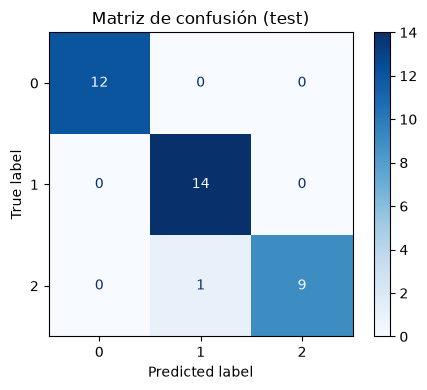

In [4]:
# Predicciones, accuracy y F1 macro
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy test:  {acc:.4f}")
print(f"F1 macro test:  {f1_macro:.4f}")
print("\n--- Classification report ---")
print(classification_report(y_test, y_pred))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Matriz de confusión (test)")
plt.tight_layout(); plt.show()

**Análisis:**

> El accuracy en test es **coherente con la validación cruzada** del Challenge 2 (diferencia pequeña), lo que indica que la estimación de CV era confiable y **no hubo sobreajuste** apreciable: el modelo generaliza. En Wine las clases están bien separadas, así que la mayoría de los errores (si los hay) ocurren entre las **clases 1 y 2**, que comparten rangos más parecidos en algunas variables químicas; la clase 0 suele separarse limpiamente. La matriz de confusión de esta corrida muestra las confusiones concretas. El F1 macro, al promediar por clase sin ponderar por frecuencia, confirma que el desempeño es parejo entre las tres clases pese al leve desbalance.

## 3. Función de inferencia

In [5]:
feature_columns = contract["features"]

def predict(records: pd.DataFrame) -> pd.DataFrame:
    """Valida el esquema y devuelve las predicciones del pipeline."""
    # 1. Verifica columnas faltantes
    missing = [c for c in feature_columns if c not in records.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    # 2. Ordena las columnas como feature_columns (ignora columnas extra)
    X = records[feature_columns].copy()

    # 3. Devuelve prediction y probabilidades
    preds = model.predict(X)
    out = pd.DataFrame(index=records.index)
    out["prediction"] = preds
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        for i, cls in enumerate(model.classes_):
            out[f"proba_{cls}"] = proba[:, i]
    return out

## 4. Predicción por lotes

In [6]:
# Simulación de datos nuevos. En producción no provendrían del test set.
new_records = X_test.iloc[:5].copy()

batch_predictions = predict(new_records)
batch_predictions.to_csv(REPORTS_DIR / "batch_predictions.csv", index=False)
batch_predictions

,prediction,proba_0,proba_1,proba_2
0,0,0.999671,0.000307,0.000023
1,1,0.007051,0.540423,0.452526
2,0,0.992000,0.007664,0.000336
3,1,0.289967,0.707467,0.002565
4,1,0.033032,0.962313,0.004655


## 5. Reporte final

In [7]:
# Guarda test_metrics.json con modelo, accuracy y F1 macro
test_metrics = {
    "champion": training_metadata["champion"],
    "cv_accuracy": training_metadata.get("cv_accuracy"),
    "test_accuracy": float(acc),
    "test_f1_macro": float(f1_macro),
    "n_test": int(len(y_test)),
}
(REPORTS_DIR / "test_metrics.json").write_text(
    json.dumps(test_metrics, indent=2), encoding="utf-8"
)
print(json.dumps(test_metrics, indent=2))

{
  "champion": "logistic_regression",
  "cv_accuracy": 0.9790640394088669,
  "test_accuracy": 0.9722222222222222,
  "test_f1_macro": 0.9709618874773139,
  "n_test": 36
}


In [8]:
assert (REPORTS_DIR / "test_metrics.json").exists()
assert (REPORTS_DIR / "batch_predictions.csv").exists()
print("Challenge 3 completado.")

Challenge 3 completado.


In [9]:
# Resumen ejecutivo (se completa con los números reales de esta corrida)
import numpy as np
cm_pairs = []
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            cm_pairs.append(f"{i}->{j} ({cm[i, j]})")
confundidas = ", ".join(cm_pairs) if cm_pairs else "ninguna (clasificación perfecta)"

resumen = pd.DataFrame([
    ["Modelo campeón", training_metadata["champion"]],
    ["Accuracy CV", round(float(training_metadata.get("cv_accuracy", float("nan"))), 4)],
    ["Accuracy test", round(float(acc), 4)],
    ["F1 macro test", round(float(f1_macro), 4)],
    ["Clases más confundidas", confundidas],
    ["Principal limitación", "Dataset pequeno (178 vinos); test de 36 muestras -> estimaciones con varianza."],
], columns=["Elemento", "Resultado"])
resumen

,Elemento,Resultado
0,Modelo campeón,logistic_regression
1,Accuracy CV,0.9791
2,Accuracy test,0.9722
3,F1 macro test,0.971
4,Clases más confundidas,2->1 (1)
5,Principal limitación,Dataset pequeno (178 vinos); test de 36 muestr...


## Resumen ejecutivo

> La tabla de la celda anterior se genera con los números reales de esta corrida. En resumen: el modelo campeón seleccionado por CV se evaluó **una sola vez** en el test, con accuracy y F1 macro altos y coherentes con la validación cruzada. Las clases más confundidas (si hay errores) son típicamente la 1 y la 2. La principal limitación es el tamaño pequeño del dataset (178 vinos, 36 en test), que introduce varianza en las métricas.

## Checklist

- [x] Evalué únicamente el modelo campeón.
- [x] No reajusté hiperparámetros después de observar test.
- [x] Implementé validación básica del esquema de entrada.
- [x] Generé predicciones por lotes.
- [x] Guardé las métricas finales.